In [1]:
import pandas as pd
import os
import sys

import geojson
from shapely import Polygon

project_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(project_dir)

from src.io import *
from src.geometry import *
from src.utils import *
from src.viz import *
from src.core import *
from src.tests import *

In [2]:
region = 'contiguous/world'
level = 'original_world'
# region = 'usa'
# level = 'states'

In [3]:
polygons, target_areas, target_positions, names, centroid = loader(region, level, year=2016)

Matched name column: 'ISO_CODE', value column: 'Population (people)'
Number of unmatched regions for year 2016: 0


In [4]:
# plot_polys(polygons, title="Original Polygons", legend=False)

In [5]:
horizontal_pairs, vertical_pairs = disjoint_pairs_horizontal_and_vertical_center(polygons)

In [6]:
fixed_points = [np.mean(p, axis=0) for p in polygons]
neighbours   = neighbouring_pairs(polygons)
shared_verts = shared_vertices_of_neighbors(polygons)

Contiguous mode 'square': 0 shared-vertex penalty terms added.
Status : optimal
Obj val: 1463.92


Contiguous mode 'square': 0 shared-vertex penalty terms added.
Status : optimal
Obj val: 1463.92


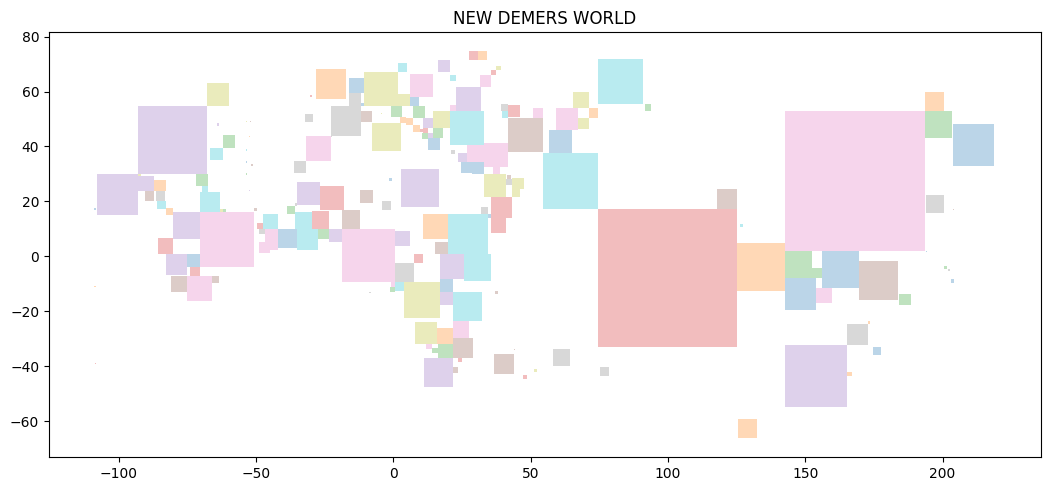

In [7]:
# DEMERS Test
new_polys, areas, status, val, leaders, target_areas = CartogramFramework_global(polygons, target_areas, fixed_points=None, shape="square", target_centers=target_positions, horizontal_pairs=horizontal_pairs, vertical_pairs=vertical_pairs, neighboring_pairs=neighbours, shared_vertices_of_neighbors=shared_verts, gamma=0.0, shape_deformation=0.0, lambda_shape=0.1, lambda_area=1.0, lambda_center=0.0, lambda_topology=1.0)
plot_polys(new_polys, title="NEW DEMERS WORLD", centroids=False, legend=False, target_centers=None, svg=True)

In [ ]:
# DORLING Test
new_polys, areas, status, val, leaders, target_areas = CartogramFramework_global(polygons, target_areas, fixed_points=None, shape="circle", target_centers=target_positions, horizontal_pairs=horizontal_pairs, vertical_pairs=vertical_pairs, neighboring_pairs=neighbours, shared_vertices_of_neighbors=shared_verts, gamma=0.0, lambda_shape=0.1, lambda_area=1.0, lambda_center=0.3, lambda_topology=1.0, lambda_repulsion=0.2, lambda_vertex_distance=0.5, vertex_distance_margin=1.3, postprocess_resolve_overlaps=True, postprocess_resolve_overlaps_resolution=1000)
plot_polys(new_polys, title="NEW DORLING WORLD", centroids=False, legend=False, target_centers=None, svg=True)

/home/kuenem/miniconda3/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


/home/kuenem/miniconda3/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


Contiguous mode 'circle': 0 shared-vertex penalty terms added.


/home/kuenem/Documents/development/lectures/Master Thesis/Cartogram Framework/src/core/CartogramFramework_3.py:720: UserWarning: Objective contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  prob = cp.Problem(objective, constraints)


In [ ]:
# NON-CONTIGUOUS Test
new_polys, areas, status, val, leaders, target_areas = CartogramFramework_global(polygons, target_areas, fixed_points=None, shape="original", target_centers=target_positions, lambda_shape=0.0, lambda_area=0.0, lambda_center=0.0, lambda_topology=0.0, lambda_contiguous=0.0, soft_mean_scale=False, t_min=1.0, t_max=1.0)
plot_polys(new_polys, title="NEW NON-CONTIGUOUS WORLD", centroids=False, legend=False, target_centers=None, svg=True)

In [ ]:
# CONTIGUOUS Test
new_polys, areas, status, val, leaders, target_areas = CartogramFramework_global(polygons, target_areas, fixed_points=None, shape="contiguous2", target_centers=target_positions, horizontal_pairs=horizontal_pairs, vertical_pairs=vertical_pairs, neighboring_pairs=neighbours, shared_vertices_of_neighbors=shared_verts, soft_mean_scale=True, lambda_contiguous=1.0, contiguous_use_topology=False, postprocess_contiguous=True, postprocess_resolve_overlaps=True, postprocess_resolve_overlaps_resolution=1000)
plot_polys(new_polys, title="NEW CONTIGUOUS WORLD", centroids=False, legend=False, target_centers=None, svg=True)

In [ ]:
# # 1. Approach 8 — density-adaptive topology (drop-in on your existing call)
# new_polys, areas, status, val, leaders, target_areas_used = CartogramFramework_global(
#     polygons=polygons,
#     target_areas=target_areas,
#     fixed_points=None,
#     shape="square",
#     target_centers=target_positions,
#     horizontal_pairs=horizontal_pairs,
#     vertical_pairs=vertical_pairs,
#     neighboring_pairs=neighbours,
#     shared_vertices_of_neighbors=shared_verts,
#     topology_density_adaptive=True,
#     topology_density_k=4,
#     topology_weight_min_scale=0.35,   # densest clusters (e.g. Europe) get this scale
#     topology_weight_max_scale=1.5,    # sparsest regions (e.g. Pacific) get this scale
# )
# plot_polys(new_polys, title="1 DEMERS WORLD — density-adaptive topology",
#            centroids=False, legend=False, target_centers=None, svg=True)

In [ ]:
# # 1. For Dorling
# new_polys, areas, status, val, leaders, target_areas_used = CartogramFramework_global(
#     polygons=polygons, target_areas=target_areas, fixed_points=None,
#     shape="circle", target_centers=target_positions,
#     horizontal_pairs=horizontal_pairs, vertical_pairs=vertical_pairs,
#     neighboring_pairs=neighbours, shared_vertices_of_neighbors=shared_verts,
#     topology_density_adaptive=True, topology_density_k=5,
#     topology_weight_min_scale=0.3, topology_weight_max_scale=1.8,
# )
# plot_polys(new_polys, title="1 DORLING WORLD — density-adaptive topology",
#            centroids=False, legend=False, target_centers=None, svg=True)

In [ ]:
# # 2. Approach 1 — staged solve (annealing into hard contiguous)
# stages = [
#     dict(shape="contiguous2", lambda_contiguous=0.3, soft_mean_scale=True,
#          t_min=0.05, t_max=8.0, contiguous_use_topology=False),
#     dict(shape="contiguous2", lambda_contiguous=1.0, soft_mean_scale=True,
#          t_min=0.02, t_max=5.0, contiguous_use_topology=True),
#     dict(shape="contiguous", contiguous_area_ratio_cap=8.0,
#          t_min=0.01, t_max=3.0,
#          postprocess_contiguous=True, postprocess_resolve_overlaps=True),
# ]

# shared_kwargs = dict(
#     target_centers=target_positions,
#     horizontal_pairs=horizontal_pairs,
#     vertical_pairs=vertical_pairs,
#     neighboring_pairs=neighbours,
#     shared_vertices_of_neighbors=shared_verts,
#     compute_leaders_flag=False,   # touching polygons don't need leader lines
# )

# result, history = solve_staged(
#     polygons, target_areas, fixed_points=None,
#     stages=stages, shared_kwargs=shared_kwargs,
# )
# new_polys, areas, status, val, leaders, target_areas_used = result
# for h in history:
#     print(h["stage"], h["status"], h["objective"])

# plot_polys(new_polys, title="2 CONTIGUOUS WORLD — staged solve",
#            centroids=False, legend=False, target_centers=None, svg=True)

In [ ]:
# # 3. Approach 3 — closed-loop overlap feedback
# result, info = solve_with_overlap_feedback(
#     polygons, target_areas, fixed_points=None,
#     max_iterations=4,
#     boost_gain=1.0,
#     convergence_area_frac=0.005,
#     solve_kwargs=dict(
#         shape="contiguous",
#         target_centers=target_positions,
#         horizontal_pairs=horizontal_pairs,
#         vertical_pairs=vertical_pairs,
#         neighboring_pairs=neighbours,
#         shared_vertices_of_neighbors=shared_verts,
#         contiguous_area_ratio_cap=8.0,
#         soft_mean_scale=True, t_min=0.02, t_max=5.0,
#         postprocess_contiguous=True,
#         compute_leaders_flag=False,
#     ),
# )
# new_polys, areas, status, val, leaders, target_areas_used = result
# print("iterations:", info["iterations"], "converged:", info["converged"])

# plot_polys(new_polys, title="3 CONTIGUOUS WORLD — overlap feedback",
#            centroids=False, legend=False, target_centers=None, svg=True)

In [ ]:
# # 4. Approach 4 — hierarchical micro-clusters (the promising one — your India-style small-vs-big-neighbor case)
# fixed_points = [np.mean(p, axis=0) for p in polygons]  # required here, see gotcha above

# result, info = solve_hierarchical_clusters(
#     polygons, target_areas, fixed_points,
#     neighboring_pairs=neighbours,
#     shared_vertices_of_neighbors=shared_verts,
#     horizontal_pairs=horizontal_pairs,
#     vertical_pairs=vertical_pairs,
#     shape="contiguous2",
#     small_area_percentile=20.0,     # "small" = bottom 20% by target area
#     min_cluster_size=2,
#     area_ratio_trigger=6.0,         # only cluster if a neighbor is 6x+ bigger
#     local_solve_kwargs=dict(
#         lambda_contiguous=1.5, t_min=0.05, t_max=6.0,
#     ),
#     outer_solve_kwargs=dict(
#         target_centers=target_positions,
#         lambda_contiguous=0.6, soft_mean_scale=True,
#         t_min=0.02, t_max=5.0,
#         postprocess_contiguous=True,
#         postprocess_resolve_overlaps=True,
#         compute_leaders_flag=False,
#     ),
# )
# new_polys, areas, status, val, leaders, target_areas_used = result
# print("clusters found:", info["clusters"])
# print("outer status:", info["outer_status"])

# plot_polys(new_polys, title="4 CONTIGUOUS WORLD — hierarchical clusters",
#            centroids=False, legend=False, target_centers=None, svg=True)

In [ ]:
# # 5. Approach 10 — Pareto search on plain Demers
# all_trials, pareto_trials = search_best_parameters(
#     polygons, target_areas, None,   # fixed_points -> centroids per trial
#     param_grid=dict(
#         lambda_shape=[0.5, 1.0, 2.0],
#         lambda_topology=[0.5, 1.0, 2.0],
#         beta=[0.0, 0.5, 1.0],
#     ),
#     fixed_kwargs=dict(
#         shape="square",
#         target_centers=target_positions,
#         horizontal_pairs=horizontal_pairs,
#         vertical_pairs=vertical_pairs,
#         neighboring_pairs=neighbours,
#         shared_vertices_of_neighbors=shared_verts,
#         compute_leaders_flag=False,
#     ),
#     max_evaluations=27,
# )
# print(f"{len(all_trials)} trials run, {len(pareto_trials)} on the Pareto front")
# for t in pareto_trials:
#     print(t["params"], t["metrics"])

# best_polys = pareto_trials[0]["polygons"]
# plot_polys(best_polys, title="5 DEMERS WORLD — Pareto pick",
#            centroids=False, legend=False, target_centers=None, svg=True)

In [ ]:
# # 5b. Approach 10 stacked on top of Approach 4 (search over cluster-detection settings)
# def hierarchical_solver(polys, targets, fps, **kw):
#     return solve_hierarchical_clusters(
#         polys, targets, fps,
#         neighboring_pairs=neighbours,
#         shared_vertices_of_neighbors=shared_verts,
#         horizontal_pairs=horizontal_pairs,
#         vertical_pairs=vertical_pairs,
#         **kw,
#     )

# fixed_points = [np.mean(p, axis=0) for p in polygons]

# all_trials, pareto_trials = search_best_parameters(
#     polygons, target_areas, fixed_points,
#     param_grid=dict(
#         small_area_percentile=[15.0, 25.0, 35.0],
#         area_ratio_trigger=[4.0, 6.0, 10.0],
#     ),
#     solve_fn=hierarchical_solver,
#     fixed_kwargs=dict(shape="contiguous2"),
#     max_evaluations=9,
# )
# print(f"{len(pareto_trials)} Pareto-optimal cluster configurations")
# best_polys = pareto_trials[0]["polygons"]
# plot_polys(best_polys, title="5b CONTIGUOUS WORLD — best cluster config",
#            centroids=False, legend=False, target_centers=None, svg=True)

Contiguous mode 'square': 0 shared-vertex penalty terms added.
Status : optimal
Obj val: 1463.92


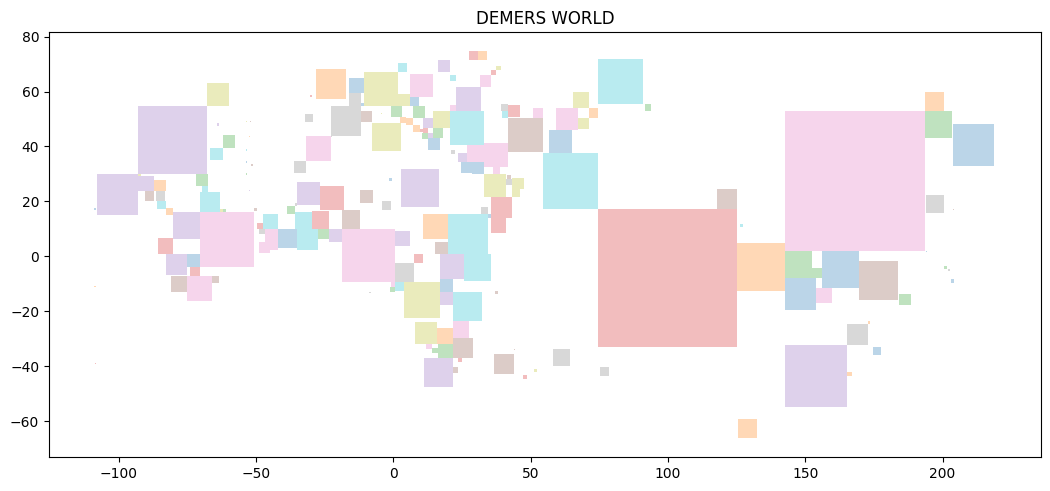

In [ ]:
# DEMERS Test
new_polys, areas, status, val, leaders, target_areas = \
    CartogramFramework_global(
        polygons=polygons,
        target_areas=target_areas,
        fixed_points=None,             # → uses polygon centroids as origins
        shape="square",             # "circle", "square", or "contiguous"
        target_centers=target_positions,
        horizontal_pairs=horizontal_pairs,
        vertical_pairs=vertical_pairs,
        neighboring_pairs=neighbouring_pairs(polygons),
        shared_vertices_of_neighbors=shared_vertices_of_neighbors(polygons),

        lambda_shape=0.1,    # small; E_square ≈ 0 once squares are pre-built # Demers: 0.1
        lambda_area=1.0,      # Demers 1.0
        lambda_center=0.0,    # TOP variant (Fig. 1 left) — purely minimise gaps # Demers: 0,0
        lambda_topology=1.0,  # paper's objective (1): min Σ h_ij + v_ij # Demers: 1.0

        gamma=0.0,            # pure E_square — REQUIRED for Demers
        beta=1.0,
        alpha=1.0,
        epsilon=1e-2,
        b=1e-2,
        t_min=0.01,
        shape_deformation=0.0,  # triggers make_square() until patch is applied
    )
plot_polys(new_polys, title="DEMERS WORLD", centroids=False, legend=False, target_centers=None, svg=True)

Contiguous mode 'circle': 0 shared-vertex penalty terms added.


/home/kuenem/Documents/development/lectures/Master Thesis/Cartogram Framework/src/core/CartogramFramework_3.py:720: UserWarning: Objective contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  prob = cp.Problem(objective, constraints)


Status : optimal
Obj val: 44661.8


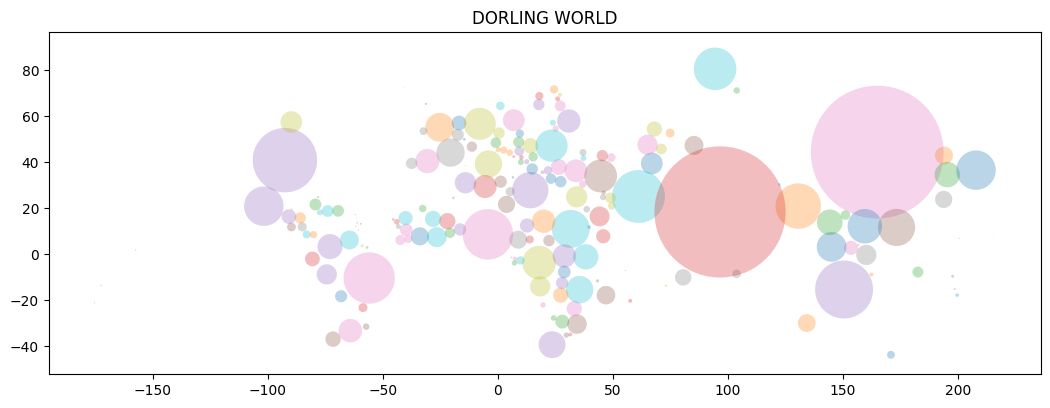

In [ ]:
# DORLING Test
new_polys, areas, status, val, leaders, target_areas = CartogramFramework_global(
    polygons        = polygons,
    target_areas    = target_areas,
    fixed_points    = None,
    shape           = "circle",
    target_centers  = target_positions,
    horizontal_pairs = horizontal_pairs,
    vertical_pairs   = vertical_pairs,
    neighboring_pairs = neighbouring_pairs(polygons),
    shared_vertices_of_neighbors=shared_vertices_of_neighbors(polygons),

    lambda_shape    = 0.1,   # small — circles form without needing shape pressure
    lambda_area     = 1.0,
    lambda_center   = 0.5,   # moderate centre fidelity keeps circles near geography
    lambda_topology = 1.0,

    gamma = 0.0,   # REQUIRED — pure E_circle
    beta  = 1.0,
    alpha = 1.0,
    epsilon = 1e-2,
    b       = 1e-2,
    t_min   = 0.01,
    t_max   = 5.0,
    shape_deformation = 0.0,   # triggers make_circle()
)
plot_polys(new_polys, title="DORLING WORLD", centroids=False, legend=False, target_centers=None, svg=True)

In [ ]:
# new_centroids = [np.mean(p, axis=0) for p in new_polys]
# measured_areas = dict(zip(names, [polygon_areanp(p) for p in new_polys]))
# target_area_dict = dict(zip(names, target_areas))

# report = evaluate_cartogram(
#     original_polygons=polygons,
#     new_polygons=new_polys,
#     original_centroids=centroid,
#     new_centroids=new_centroids,
#     measured_areas=measured_areas,
#     target_areas=target_area_dict,
#     names=names,
#     adjacency_new_tolerance=0.0,  # bump up for Dorling/non-contiguous runs
# )

In [ ]:
# print(report)

In [ ]:
# original_areas = [polygon_areanp(poly) for poly in polygons]

# for area, target_area, original_area in zip(areas, target_areas, original_areas):
#     print(f"Area: {area:.2f}, Target Area: {target_area:.2f}, Difference: {abs(area - target_area):.2f}")
#     print(f"Original Area: {original_area:.2f}, Difference from Original: {abs(area - original_area):.2f}")


prevent_vertex_penetration False Master on/off switch
penetration_pairs None Restrict to specific pairs (all neighbours if None)
penetration_margin 0.0 Extra clearance beyond the border edge
penetration_use_all_edges False False = shared border edges only (recommended); True = all edges of j

Contiguous mode 'original': 0 shared-vertex penalty terms added.
Status : infeasible
Obj val: inf
  Tips for contiguous mode:
    • Raise contiguous_area_ratio_cap (skips locking large-ratio pairs)
    • Set contiguous_use_topology=False to drop topology terms
    • Switch to shape='contiguous2' (soft penalty instead of hard equality)


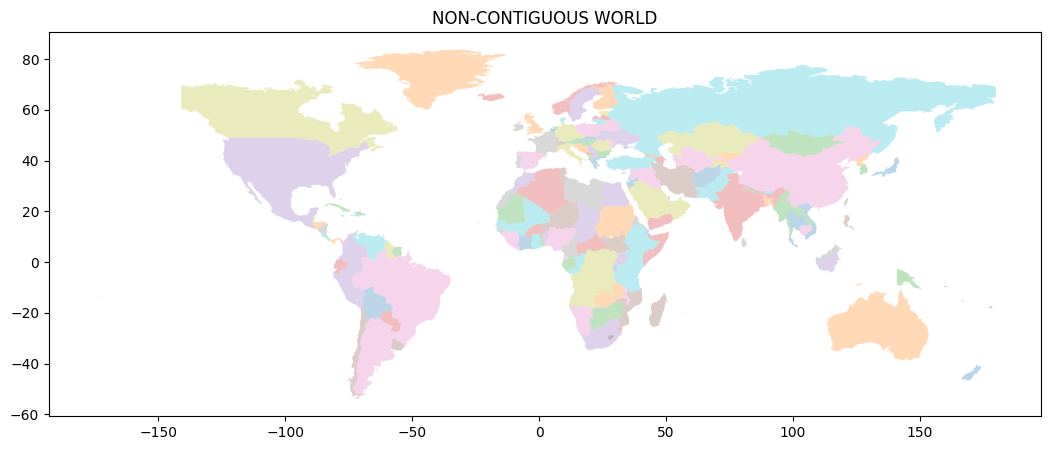

In [ ]:
# NON-CONTIGUOUS FAILED Test
# Force t fixed at 1, no shape deformation, no contiguous pulling
new_polys, areas, status, val, leaders, target_areas = CartogramFramework_global(
    polygons          = polygons,
    target_areas      = target_areas,   # unchanged
    fixed_points      = None,
    shape             = "original",     # no contiguous pulling
    target_centers    = target_positions,
    lambda_shape      = 0.0,            # ← disable shape term
    lambda_area       = 0.0,            # ← disable area term
    lambda_center     = 0.0,
    lambda_topology   = 0.0,
    lambda_contiguous = 0.0,            # ← disable contiguous
    soft_mean_scale   = False,          # ← disable mean scale
    t_min             = 1.0,            # ← pin t to exactly 1
    t_max             = 1.0,            # ← pin t to exactly 1
)
plot_polys(new_polys, title="NON-CONTIGUOUS WORLD", centroids=False, legend=False, target_centers=None, svg=True)

Why the Map Changes Despite Identity Targets
1. t_min = 0.01 and t_max = 1.5 clip the homothetic scales
The original polygon has some vertices with scale t_ik = 1.0 (identity). But your bounds force t ∈ [0.01, 1.5]. If any original vertex had an implicit scale outside this range, it gets clipped. More importantly, the optimizer is free to move t anywhere in [0.01, 1.5] — it will, because other objective terms pull it away from 1.0.
2. lambda_shape = 0.5 actively deforms polygons
The shape term minimizes deviation from the target shape (controlled by gamma = 1.0). With gamma = 1.0 the shape term is purely the E_target component — deformation toward a regularized/smoothed version of the polygon, not toward the original vertices. This will move vertices even when areas are unchanged.
3. lambda_contiguous = 80.0 with contiguous2 moves shared vertices
The soft penalty pulls shared border vertices of neighbours toward each other. Even at identity areas, if two polygons' shared vertices don't perfectly coincide in the initial geometry (numerical tolerance), the penalty drags them together — changing both polygons.
4. soft_mean_scale = True with lambda_mean_scale = 1e4 enforces mean scale ≈ target
The mean scale penalty forces mean(t_ik) ≈ s_i where s_i is derived from target_area / original_area. Even at identity, if the polygon vertices don't distribute perfectly around the fixed point, the mean of the t_ik values at the original geometry ≠ 1.0 exactly, so the solver shifts them.
5. fixed_points = None means centroids are recomputed
With fixed_points = None, the framework computes fixed points (likely centroids or weighted centroids) internally. The homothetic transform is v'_ik = m_i + t_ik * d_ik where d_ik = v_ik - fp_i. If fp_i is not exactly the centroid used in the direction computation, the "identity" transform t_ik = 1 doesn't reconstruct the original polygon exactly.


Contiguous mode 'contiguous': 9322 shared-vertex constraints added.
Status : optimal
Obj val: 13412.1


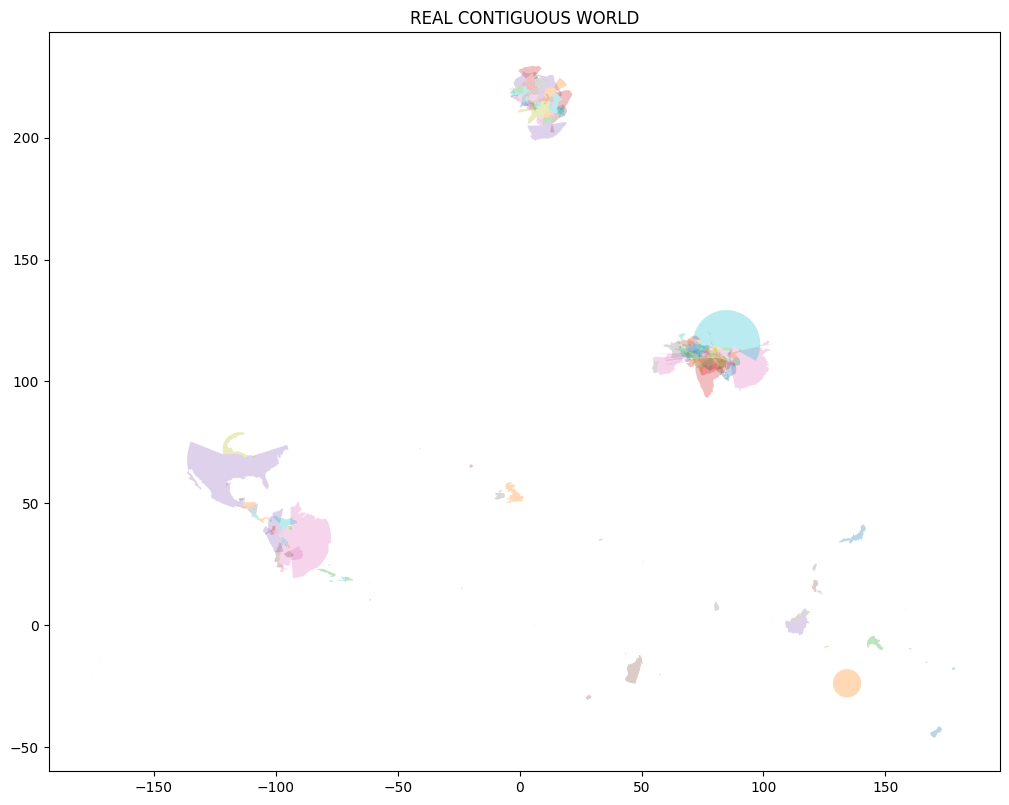

In [ ]:
# Test with Cartogram Framework 0 without post processing
new_polys, areas, status, val, leaders, target_areas = CartogramFramework_global(
    polygons        = polygons,
    target_areas    = target_areas,
    fixed_points    = None,
    shape           = "contiguous",
    target_centers  = target_positions,
    horizontal_pairs = horizontal_pairs,
    vertical_pairs   = vertical_pairs,
    neighboring_pairs = neighbouring_pairs(polygons),
    shared_vertices_of_neighbors = shared_vertices_of_neighbors(polygons),

    lambda_shape      = 0.5,
    lambda_area       = 1.0,
    lambda_center     = 0.0,
    lambda_topology   = 0.0,
    lambda_contiguous = 80.0,       # only for contiguous2 The higher the closer to contiguous
    soft_mean_scale   = True,       # Makes mean(t) = s soft not hard
    lambda_mean_scale = 1e-10,        # Weight of the hardness of soft_mean_scale. The higher the closer to soft_mean_scale = False
    t_min = 0.01,
    t_max = 1.5,
    lambda_vertex_distance = 10.0,
    vertex_distance_margin = 1.5,
    lambda_repulsion  = 0.0,
    contiguous_area_ratio_cap = np.inf,
    contiguous_use_topology   = False,
    gamma = 1.0,
    beta  = 1.0,
    alpha = 1.0,
    epsilon = 1e-2,
    b       = 1e-2,
)
plot_polys(new_polys, title="REAL CONTIGUOUS WORLD", centroids=False, legend=False, target_centers=None, svg=True)

Contiguous mode 'contiguous2': 9322 shared-vertex penalty terms added.


/home/kuenem/Documents/development/lectures/Master Thesis/Cartogram Framework/src/core/CartogramFramework_3.py:721: UserWarning: Objective contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  prob.solve(solver=cp.CLARABEL, verbose=False)


Status : optimal
Obj val: 1.76364e+07


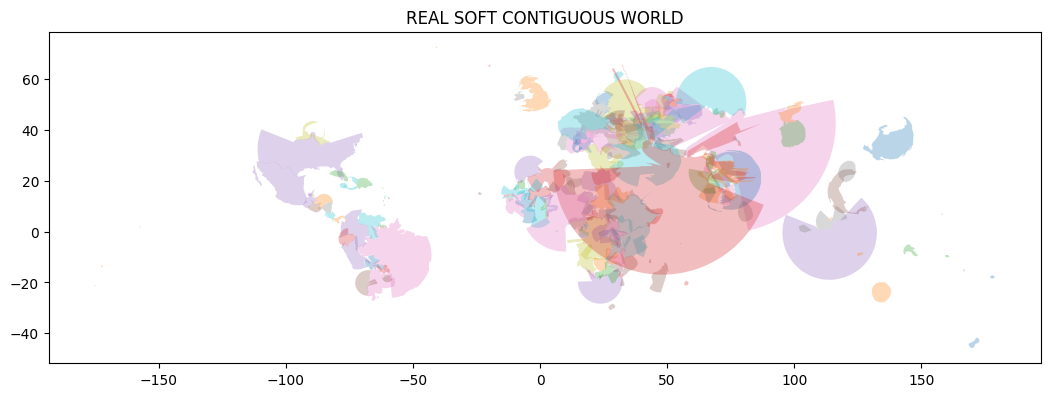

In [ ]:
# Test with Cartogram Framework 0 without post processing
new_polys, areas, status, val, leaders, target_areas = CartogramFramework_global(
    polygons        = polygons,
    target_areas    = target_areas,
    fixed_points    = None,
    shape           = "contiguous2",
    target_centers  = target_positions,
    horizontal_pairs = horizontal_pairs,
    vertical_pairs   = vertical_pairs,
    neighboring_pairs = neighbouring_pairs(polygons),
    shared_vertices_of_neighbors = shared_vertices_of_neighbors(polygons),

    lambda_shape      = 0.5,
    lambda_area       = 1.0,
    lambda_center     = 0.0,
    lambda_topology   = 0.0,
    lambda_contiguous = 80.0,       # only for contiguous2 The higher the closer to contiguous
    soft_mean_scale   = True,       # Makes mean(t) = s soft not hard
    lambda_mean_scale = 1e4,        # Weight of the hardness of soft_mean_scale. The higher the closer to soft_mean_scale = False
    t_min = 0.01,
    t_max = 15,
    lambda_vertex_distance = 10.0,
    vertex_distance_margin = 1.5,
    lambda_repulsion  = 0.0,
    contiguous_area_ratio_cap = np.inf,
    contiguous_use_topology   = False,
    gamma = 1.0,
    beta  = 1.0,
    alpha = 1.0,
    epsilon = 1e-2,
    b       = 1e-2,
)
plot_polys(new_polys, title="REAL SOFT CONTIGUOUS WORLD", centroids=False, legend=False, target_centers=None, svg=True)

In [ ]:
# new_polys, areas, status, val, leaders, target_areas = CartogramFramework_global(
#     polygons        = polygons,
#     target_areas    = target_areas,
#     fixed_points    = None,
#     shape           = "contiguous",
#     target_centers  = target_positions,
#     horizontal_pairs = horizontal_pairs,
#     vertical_pairs   = vertical_pairs,
#     neighboring_pairs = neighbouring_pairs(polygons),
#     shared_vertices_of_neighbors = shared_vertices_of_neighbors(polygons),

#     lambda_shape      = 0.5,
#     lambda_area       = 1.0,
#     lambda_center     = 0.0,
#     lambda_topology   = 0.0,
#     lambda_contiguous = 80.0,
#     soft_mean_scale   = True,
#     lambda_mean_scale = 1e4,
#     t_min = 0.01,
#     t_max = 50.5,
#     lambda_vertex_distance = 10.0,
#     vertex_distance_margin = 1.5,
#     lambda_repulsion  = 0.0,
#     contiguous_area_ratio_cap = np.inf,
#     contiguous_use_topology   = False,
#     gamma = 1.0,
#     beta  = 1.0,
#     alpha = 1.0,
#     epsilon = 1e-2,
#     b       = 1e-2,

#     postprocess_contiguous         = True,
#     postprocess_snap_method        = "mean",
#     # postprocess_shrink             = 1.0,

#     postprocess_resolve_overlaps   = True,   # step 4: clip overlaps, record losses
#     # postprocess_resolve_overlaps_resolution = 1000.0,

# )
# plot_polys(new_polys, title="REAL CONTIGUOUS WORLD", centroids=False, legend=False, target_centers=None, svg=True)

In [ ]:
# new_polys, areas, status, val, leaders, target_areas = CartogramFramework_global(
#     polygons        = polygons,
#     target_areas    = target_areas,
#     fixed_points    = None,
#     shape           = "contiguous2",
#     target_centers  = target_positions,
#     horizontal_pairs = horizontal_pairs,
#     vertical_pairs   = vertical_pairs,
#     neighboring_pairs = neighbouring_pairs(polygons),
#     shared_vertices_of_neighbors = shared_vertices_of_neighbors(polygons),

#     lambda_shape      = 0.5,
#     lambda_area       = 1.0,
#     lambda_center     = 0.0,
#     lambda_topology   = 0.0,
#     lambda_contiguous = 80.0,
#     soft_mean_scale   = True,
#     lambda_mean_scale = 1e4,
#     t_min = 0.01,
#     t_max = 1.5,
#     lambda_vertex_distance = 10.0,
#     vertex_distance_margin = 1.5,
#     lambda_repulsion  = 0.0,
#     contiguous_area_ratio_cap = np.inf,
#     contiguous_use_topology   = False,
#     gamma = 1.0,
#     beta  = 1.0,
#     alpha = 1.0,
#     epsilon = 1e-2,
#     b       = 1e-2,

#     postprocess_contiguous         = True,
#     postprocess_snap_method        = "mean",
#     # postprocess_shrink             = 1.0,

#     postprocess_resolve_overlaps   = True,   # step 4: clip overlaps, record losses
#     # postprocess_resolve_overlaps_resolution = 2000.0,

# )
# plot_polys(new_polys, title="CONTIGUOUS WORLD", centroids=False, legend=False, target_centers=None, svg=True)

In [ ]:
# original_areas = [polygon_areanp(poly) for poly in polygons]

# for area, target_area, original_area in zip(areas, target_areas, original_areas):
#     print(f"Area: {area:.2f}, Target Area: {target_area:.2f}, Difference: {abs(area - target_area):.2f}")
#     print(f"Original Area: {original_area:.2f}, Difference from Original: {abs(area - original_area):.2f}")


In [ ]:
base_path = "/home/kuenem/Documents/development/lectures/Master Thesis/Cartogram Framework/"
path = os.path.join(base_path, "data/geojson/contiguous/world/world.geojson")
path = os.path.join(base_path, "R/world_cartogram_2010_ncont.geojson")
path = os.path.join(base_path, "R/world_cartogram_2010_dorling.geojson")
path = os.path.join(base_path, "R/world_cartogram_2010_cont.geojson")

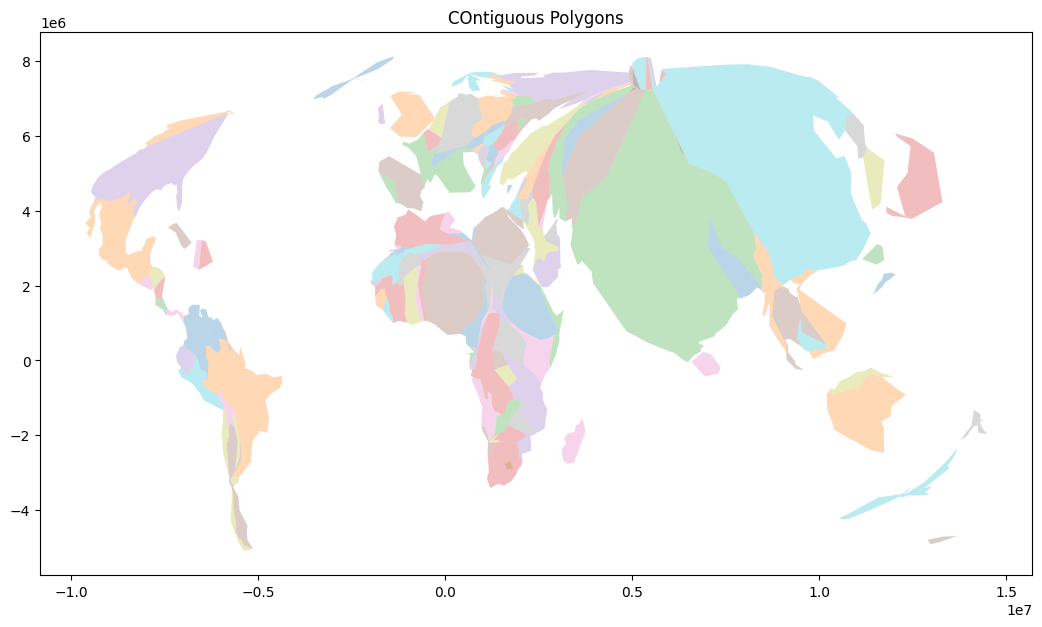

In [ ]:
polygons, target_areas, target_positions, names, centroid = get_polygon_data(path, exclude=None)
# print(polygons)
plot_polys(polygons, title="COntiguous Polygons", legend=False)

In [ ]:
def cartographic_error(df, polygons, names, index=None):
    if index is not None:
        df = df.set_index("ISO_CODE")
    total_target = 0
    total_area = 0
    normalized_area = []
    error_cartographic = []

    for polygon, name in zip(polygons, names):
        target = df.loc[name, "Population (people)"]
        total_target += target
        total_area += polygon_areanp(polygon)

    c = total_area/total_target
    
    for polygon, name in zip(polygons, names):
        target = df.loc[name, "Population (people)"]
        norm_area = polygon_areanp(polygon)/c
        normalized_area.append(norm_area)

        e_cartographic = abs(norm_area - target) / norm_area
        error_cartographic.append(e_cartographic)

    e_c = pd.Series(error_cartographic)
    print(e_c.describe())

    return error_cartographic


In [ ]:
df = pd.read_csv(os.path.join(base_path, "data/statistics/contiguous/world/world.csv"))
df = df.set_index("ISO_CODE")

In [ ]:
f = cartographic_error(df, new_polys, names)

count     157.000000
mean       70.205119
std       271.658943
min         0.071350
25%         0.656331
50%         0.969653
75%         9.149615
max      2407.391981
dtype: float64


In [ ]:
m = cartographic_error(df, polygons, names)

count    157.000000
mean       0.289738
std        1.206952
min        0.001673
25%        0.069825
50%        0.076339
75%        0.144601
max       14.804221
dtype: float64


In [ ]:
total_target = 0
total_area = 0
for polygon, name in zip(polygons, names):
    poly = Polygon(polygon)
    target = df.loc[name, "Population (people)"]
    total_target += target
    total_area += poly.area
    # print(f"Polygon: {name}, Target: {target}, Area: {polygon_areanp(polygon):.2f}, Shapely Area: {poly.area:.2f}")

In [ ]:
c = total_area/total_target
normalized_area = []
error_cartographic = []
for polygon, name in zip(polygons, names):
    target = df.loc[name, "Population (people)"]
    norm_area = polygon_areanp(polygon)/c
    normalized_area.append(norm_area)

    e_cartographic = abs(norm_area - target) / norm_area
    error_cartographic.append(e_cartographic)
print(error_cartographic)

[np.float64(0.1446005007150347), np.float64(0.07088310458524742), np.float64(0.07374980129565556), np.float64(0.08092248967294775), np.float64(0.2163898797162552), np.float64(0.06021111529701534), np.float64(0.05900185988909726), np.float64(0.07159498518273548), np.float64(0.03952915330813458), np.float64(0.3825566142741883), np.float64(0.06998173893130914), np.float64(1.065035593791076), np.float64(0.06987749195353209), np.float64(0.07425423673426121), np.float64(0.08566190425550618), np.float64(0.5800380596998633), np.float64(0.06282583654821523), np.float64(0.09627248048201918), np.float64(0.22015870116088493), np.float64(0.27511595252325555), np.float64(0.07138283011077112), np.float64(0.06813667433009507), np.float64(0.7532108643275424), np.float64(0.056425871035337874), np.float64(0.22401205242265837), np.float64(0.02911704277635672), np.float64(0.07246519910669078), np.float64(0.004116785788059389), np.float64(0.08508617299553399), np.float64(0.1405288065113283), np.float64(0.07

In [ ]:
for polygon, name in zip(polygons, names):
    target = df.loc[name, "Population (people)"]
    poly = Polygon(polygon)
    print(f"Error: {target/total_target - poly.area/total_area:.2f}")

Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: 0.01
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: 0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: 0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: 0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: 0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.01
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: 0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: 0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: 0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: 0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: 0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: 0.00
Error: 0.01
Error: -0.00
Error: -0.00
Error: -0.00
Error: 0.00
Error: -0.00
Error: -0.00